# 의료비 예측 MLP 회귀 모델  

### 실습 순서
- Kaggle 에서 데이터(csv)다운로드
    - https://www.kaggle.com/datasets/mirichoi0218/insurance?select=insurance.csv
-수치형/범주형 데이터 확인
- train / valid / test 데이터 분리
- 수치형 정규화 / 범주형 One-Hot Encoding
- target 값 로그 변환 및 표준화
- Pytorch Tensor형태로 데이터 변환
- Dataset / Loader로 미니배치 학습 준비
- 다층 퍼셉트론(MLP) 회귀 모델 설계
- BatchNorm, Dropout, SiLU 활성화 함수
- HuberLoss 손실함수, AdamW 최적화 함수, Scheduler, Gradient Clipping, EarlyStopping
- 학습 및 검증
- 지표확인 / 시각화
- test 데이터로 최종 평가

### 1. 라이브러리 import

In [57]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from sklearn.compose import ColumnTransformer               # 컬럼별 전처리 적용
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score   # 회귀 평가 지표

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from tqdm.auto import tqdm
import kagglehub

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [58]:
# 시드값 고정,  CPU/GPU 사용 장치 설정
SEED = 42

random.seed(SEED)                   # python random
np.random.seed(SEED)                # numpy random
torch.manual_seed(SEED)             # Pytorch CPU
torch.cuda.manual_seed_all(SEED)    # Pytorch GPU

# device설정 (GPU가능시 GPU, 불가시 CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("사용장치 : ", device)



사용장치 :  cpu


### 2. 데이터 다운로드

In [59]:
data_path = kagglehub.dataset_download("mirichoi0218/insurance", path = "insurance.csv" )

df = pd.read_csv(data_path)
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [60]:
print(df.shape)

df.info()

(1338, 7)
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [61]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [62]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

컬럼 설명
- age : 나이
- sex : 성별
- bmi : 체질량 지수
- children : 부양 자녀 수
- smoker : 흡연 여부
- region : 거주 지역
- charges : 의료비 청구 금액(target)

In [63]:
# 범주형 컬럼

categorical_cols = ['sex','smoker','region']

for col in categorical_cols:
    print(df[col].value_counts())   # 범주형 값 갯수

sex
male      676
female    662
Name: count, dtype: int64
smoker
no     1064
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


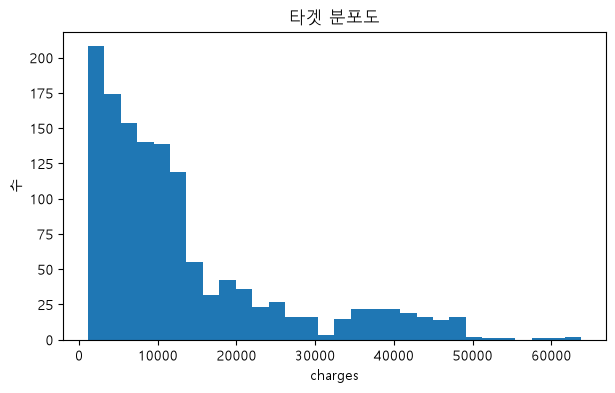

In [64]:
# target 컬럼 분포도
plt.figure(figsize = (7,4))
plt.hist(df['charges'], bins = 30)
plt.title('타겟 분포도')
plt.xlabel('charges')
plt.ylabel('수')
plt.show()

타겟 데이터는 적은 치료비가 많은 상태

<Figure size 700x400 with 0 Axes>

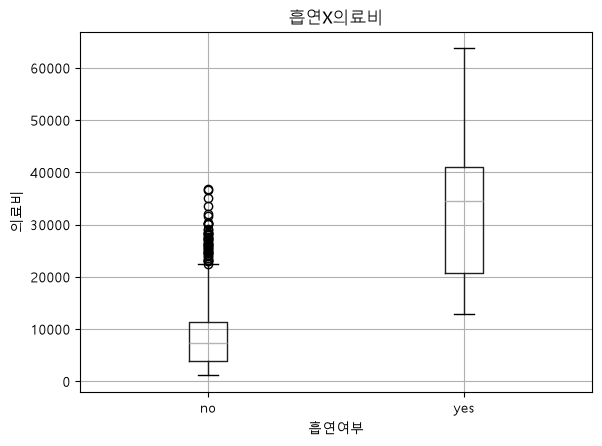

In [65]:
# 흡연 여부에 따른 의료비 차이
plt.figure(figsize = (7,4))
df.boxplot(column = 'charges', by = 'smoker')
plt.title('흡연X의료비')
plt.suptitle("")
plt.xlabel('흡연여부')
plt.ylabel('의료비')
plt.show()

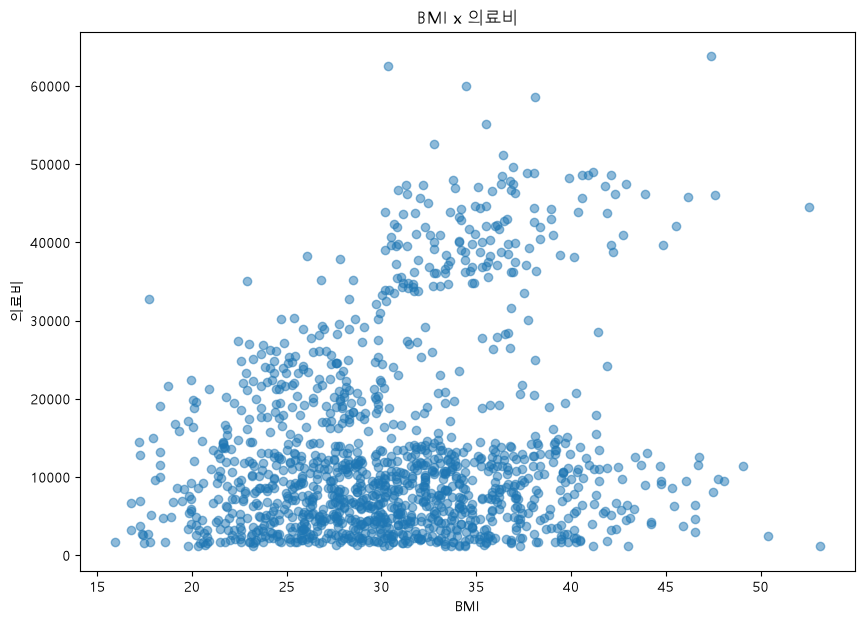

In [66]:
# BMI와 의료비 관계
plt.figure(figsize = (10,7))
plt.scatter(df['bmi'],df['charges'], alpha= 0.5,)    # BMI와 의료비 관계 산점도
plt.title('BMI x 의료비')
plt.suptitle("")
plt.xlabel('BMI')
plt.ylabel('의료비')
plt.show()

### 3. 입력 데이터와 정답 데이터 분리

In [67]:
X = df.drop(columns= 'charges')
y= df['charges']

print(X.shape,y.shape)

(1338, 6) (1338,)


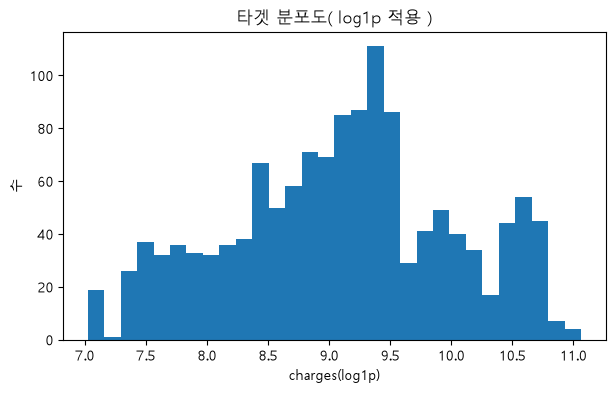

In [68]:
# target 컬럼이 왼쪽으로 치우친 형태이므로 로그 변환 적용
y_log = np.log1p(y)

plt.figure(figsize = (7,4))
plt.hist(y_log , bins = 30)
plt.title('타겟 분포도( log1p 적용 )')
plt.xlabel('charges(log1p)')
plt.ylabel('수')
plt.show()

log 변환 적용해주니 정규 분포와 가까워진 형태로 변환됨

### 4. train / valid / test 데이터 분리

In [69]:
# test데이터를 8:2 비율로 나눈다
X_train_valid,X_test,y_train_valid,y_test = train_test_split(
    X,y_log,
    test_size= 0.2,
    random_state= SEED,
)

# 남은 80% 중 8:2 비율로 Train/valid 데이터를 나눈다.
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_valid,y_train_valid,
    test_size= 0.2,
    random_state= SEED,
)



print(f"X_trian :{X_train.shape},X_valid:{X_valid.shape}X_Test:{X_test.shape}")
print(f"y_trian :{y_train.shape},y_valid:{y_valid.shape}y_Test:{y_test.shape}")

X_trian :(856, 6),X_valid:(214, 6)X_Test:(268, 6)
y_trian :(856,),y_valid:(214,)y_Test:(268,)


### 5. 전처리 Pipeline 구성
- 수치형 : 정규화
- 범주형 : One-Hot Encoding


In [70]:
# 범주형, 수치형 컬럼 구분
categorical_features = ['sex', 'smoker', 'region']
numeric_features = ['age', 'bmi', 'children']

onehot_encoder = OneHotEncoder(
    handle_unknown='ignore',   # 학습시 없던 범주가 입력되어도 오류 없이 무시
    sparse_output=False        # True : 희소 행렬, False : 일반 Numpy 배열로 반환
)

# 수치형 전처리 : 결측값 중앙값 대체, 표준화
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy='median')),
    ("scaler", StandardScaler())
])

# 범주형 전처리 : 결측값 최빈값 대체, 원핫인코딩
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy='most_frequent')),
    ("onehot", onehot_encoder)
])

# 컬럼별 전처리 통합
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),  # 수치형 컬럼에는 수치형 전처리
    ("category", categorical_pipeline, categorical_features)  # 범주형 컬럼에는 범주형 전처리
])

In [71]:
# preprocessor 전처리 도구로 학습 및 변환

X_train_scaled = preprocessor.fit_transform(X_train)
X_valid_scaled = preprocessor.transform(X_valid)
X_test_scaled = preprocessor.transform(X_test)


print(X_train_scaled.shape,X_valid_scaled.shape,X_test_scaled.shape)

(856, 11) (214, 11) (268, 11)


In [72]:
# target 데이터를 표준화 : target데이터의 범위가 클때 학습이 불안정해질 수 있어 표준화

y_mean = y_train.mean() # train target 평균
y_std = y_train.std()   # train target 표준 편차

# train 기준 평균과 표준편차로 모든 target데이터 표준화
y_train_scaled = (y_train - y_mean) / y_std
y_valid_scaled = (y_valid - y_mean) / y_std
y_test_scaled = (y_test - y_mean) / y_std

print(f"target mean : {y_mean} , target_std : {y_std}") # 표준화에 사용한 평균, 표준 편차

target mean : 9.104843701853595 , target_std : 0.9082830243269455


### 6. Pytorch Tensor 변환

In [73]:
# 입력 데이터 Tensor로 변환
X_train_tensor = torch.FloatTensor(X_train_scaled)
X_valid_tensor = torch.FloatTensor(X_valid_scaled)
X_test_tensor =torch.FloatTensor(X_test_scaled)

# 정답데이터 Tensor로 변환 (Series형태 -> -> )
y_train_tensor = torch.tensor(y_train_scaled.to_numpy(),dtype = torch.float32).reshape(-1,1)
y_valid_tensor = torch.tensor(y_valid_scaled.to_numpy(),dtype = torch.float32).reshape(-1,1)
y_test_tensor = torch.tensor(y_test_scaled.to_numpy(),dtype = torch.float32).reshape(-1,1)

print("X_train_tensor : ",X_train_tensor.size())
print("X_valid_tensor : ", X_valid_tensor.size())
print("X_test_tensor : ", X_test_tensor.size())
print("y_train_tensor : ", y_train_tensor.size())
print("y_valid_tensor : ", y_valid_tensor.size())
print("y_test_tensor : " ,y_test_tensor.size())

X_train_tensor :  torch.Size([856, 11])
X_valid_tensor :  torch.Size([214, 11])
X_test_tensor :  torch.Size([268, 11])
y_train_tensor :  torch.Size([856, 1])
y_valid_tensor :  torch.Size([214, 1])
y_test_tensor :  torch.Size([268, 1])


### 7. TensorDataSet / DataLoader로 미니배치 데이터 준비

In [74]:
train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
valid_dataset = TensorDataset(X_valid_tensor,y_valid_tensor)
test_dataset = TensorDataset(X_test_tensor,y_test_tensor)

BATCH_SIZE = 32

train_loader =DataLoader(train_dataset, batch_size= BATCH_SIZE, shuffle= True)
valid_loader =DataLoader(valid_dataset, batch_size= BATCH_SIZE, shuffle= False)
test_loader =DataLoader(test_dataset, batch_size= BATCH_SIZE, shuffle= False)

print(len(train_loader)*32, len(valid_loader)*32, len(test_loader)*32)

864 224 288


### 8. 다층 퍼셉트론 회귀 모델 설계

In [75]:
class RegressionMLP(nn.Module):

    def __init__(self, input_dim, hidden_dims=[128,64,32], dropout = 0.2):
        super().__init__()  # nn.module 초기화

        layers = [] # 모델 레이어르 순서대로 저장할 리스트

        prev_dim = input_dim    # 현재 층

        #입력층 + 은닉층 구성
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))   # 배치 정규화 (평균 0, 표준편차 1) : 수치 안정화 -> 학습 안정화
            layers.append(nn.SiLU())                    # 비선형 활성화 함수
            layers.append(nn.Dropout(dropout))          # 랜덤하게 20%노드를 끔 (과적합 완화)
            prev_dim = hidden_dim       

        # 출력층
        layers.append(nn.Linear(prev_dim,1))    # 회귀 : 예측값 1개

        self.net = nn.Sequential(*layers)

    def forward(self,x):
        return self.net(x)

In [76]:
input_dim = X_train_tensor.size(-1)     # 입력 특성 개수

model = RegressionMLP(input_dim = input_dim).to(device)

model

RegressionMLP(
  (net): Sequential(
    (0): Linear(in_features=11, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): SiLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): SiLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): SiLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)

### 9. 손실함수, Optimizer, Scheduler설정

In [77]:
# HuberLoss 손실함수 : 작은 오차는 MSE, 큰 오차는 MAE 방식으로 작동한다.
criterion = nn.HuberLoss(delta =1.0)

# AdamW 최적화 함수 : Adam + weight decay(가중치 감쇠)로 안정적인 학습
optimizer = torch.optim.AdamW(
    model.parameters(), # 학습할 모델 파라미터
    lr = 0.001,         # 학습률
    weight_decay=0.01   # 가중치 감쇠율 (과적합 완화)
)
# val_loss 기준으로 일정 epoch동안 개선없을시 학습률 감소
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,      # 조절할 최적화 함수
    mode = "min",   # validation_loss는 최소화해야되므로 min
    factor= 0.5,    # 감소 비율
    patience= 5     # 5 epoch 동안 개선없으면 감소

)

### 10. Early Stopping
- validation_loss가 일정 epoch동안 개선없으면 학습 종료
- 과적합 완화 목적


In [78]:
# EarlyStopping : 일정 epoch 동안 성능이 좋아지지 않으면 학습을 멈추는 도구

class EarlyStopping:
    def __init__(self, patience = 20, min_delta = 0.0):
        self.patience = patience    # 개선이 없을때 기다릴 epoch 수
        self.min_delta = min_delta  # 개선으로 인정할 최소 손실 감소량
        self.best_loss = np.inf     # 현재까지 가장 낮은 valid loss
        self.counter = 0            # 개선이 없던 epoch 수
        self.best_state = None      # 가장 성능이 좋은 모델의 가중치
        self.should_stop = False    # 학습 중단 여부 플래그

    def step(self,valid_loss,model):
        # 최소 손실 갱신시
        if valid_loss < self.best_loss -self.min_delta:
            self.best_loss = valid_loss
            self.counter = 0


            # 가장 좋은 모델의 가중치 저장
            self.best_state = {
                key : value.detach().cpu().clone() 
                for key,value in model.state_dict().items()
            }

        else:
            self.counter+=1

            # patience 동안 개선이 없을시
            if self.counter >= self.patience:
                self.should_stop = True     # 학습 중단 신호

### 11. 학습 및 검증
- 학습
1. 예측값 계산
2. 손실 계산
3. 기존 기울기 초기화
4. 오차역전파 : 기울기 계산
5. Gridient Clipping 
6. 가중치 업데이트

In [79]:
# 학습 함수
def train_one_epoch(model, data_loader, criterion, optimizer, device, max_grad_norm=1.0):
    model.train()    # 학습 모드
    total_loss = 0   # 전체 손실

    # 미니배치 32개 단위로 반복
    for X_batch, y_batch in data_loader:
        X_batch = X_batch.to(device)  # 입력 데이터를 CPU/GPU로 이동
        y_batch = y_batch.to(device)  # 정답 데이터를 CPU/GPU로 이동

        optimizer.zero_grad()     # 이전 step 기울기 초기화
        output = model(X_batch)   # 예측값 계산
        loss = criterion(output, y_batch)  # 손실 계산

        loss.backward()   # 기울기 계산
        # Gridient Clipping(기울기 폭주 방지)
        nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()  # 가중치 업데이트

        total_loss += loss.item() * len(X_batch)  # 배치 손실을 데이터 수만큼 누적 
    
    return total_loss / len(data_loader.dataset)  # 데이터 1개당 평균 손실 반환

# 검증 함수
def evalute_loss(model, data_loader, criterion, device):
    model.eval()   # 평가 모드로 설정
    total_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device) # 입력 데이터 장치로 이동
            y_batch = y_batch.to(device) # 정답 데이터 장치로 이동

            output = model(X_batch) # 예측값 계산
            loss = criterion(output, y_batch) # 손실값 계산

            total_loss += loss.item() * len(X_batch) # 배치 손실을 데이터 수만큼 누적
    
    return total_loss / len(data_loader.dataset)  # 데이터 1개당 평균 손실 반환

### 12. 모델 학습

In [80]:
EPOCHS = 200  # 최대 학습 횟수

# 20번 동안 최소 개선 기준 0.0001 이상 개선되지 않으면 학습 중단
early_stopping = EarlyStopping(patience=20, min_delta=0.0001)

history = {
    'train_loss': [],
    'valid_loss': [],
    'lr': []
}

for epoch in tqdm(range(1, EPOCHS + 1), desc='Training'):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    valid_loss = evalute_loss(model, valid_loader, criterion, device)

    scheduler.step(valid_loss)  # valid_loss 기준으로 학습률 조정

    current_lr = optimizer.param_groups[0]["lr"]    # 현재 학습률 확인

    history['train_loss'].append(train_loss)
    history['valid_loss'].append(valid_loss)
    history['lr'].append(current_lr)

    early_stopping.step(valid_loss, model)  # valid_loss 기준으로 EarlyStopping 상태 업데이트

    # 20번 동안 개선 없을시 flag True가 되면
    if early_stopping.should_stop:
        print(f"{epoch} Epoch에서 Early Stopping 작동하여 학습 중지!")
        break

if early_stopping.best_state is not None:
    # 가장 성능이 좋은 모델의 가중치 복원
    model.load_state_dict(early_stopping.best_state)

Training:   0%|          | 0/200 [00:00<?, ?it/s]

56 Epoch에서 Early Stopping 작동하여 학습 중지!


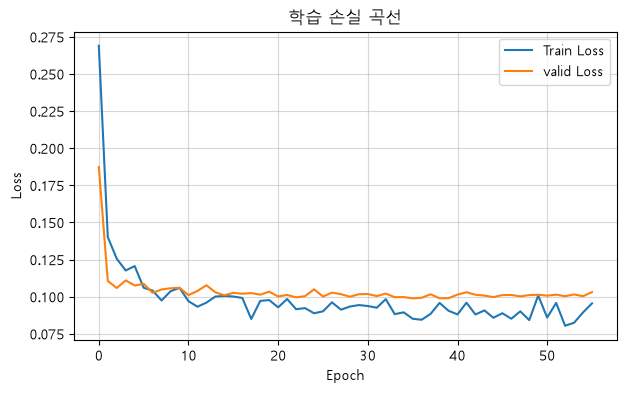

In [81]:
# 학습 손실 곡선 시각
plt.figure(figsize=(7,4))
plt.plot(history['train_loss'],label='Train Loss')
plt.plot(history['valid_loss'],label='valid Loss')
plt.title('학습 손실 곡선')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha =0.5)
plt.show()


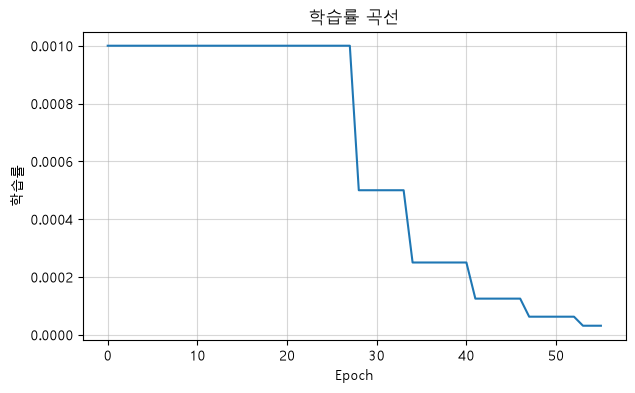

In [82]:
# 학습률 곡선 시각화
plt.figure(figsize=(7,4))
plt.plot(history['lr'])
plt.title('학습률 곡선')
plt.xlabel('Epoch')
plt.ylabel('학습률')
plt.grid(alpha =0.5)
plt.show()

### 14. 테스트 데이터로 최종 평가

In [83]:
# 타겟값을 역변환 시켜주는 함수
def inverse_target(y_scaled):
    y_log_restored = y_scaled * y_std + y_mean  # 정규화 복원

    return np.expm1(y_log_restored)  # log1p 역변환(복원)

def predict_loader(model, data_loader, device):
    model.eval()       # 평가 모드
    preds = []         # 예측값
    target_list = []   # 정답값

    # 예측시 기울기 계산 비활성화
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)  # 입력 데이터만 장치로 이동

            output = model(X_batch)  # 모델 출력값
            
            preds.append(output.cpu().numpy())  # 예측값을 CPU Numpy로 변환해 저장
            target_list.append(y_batch.numpy())

    preds = np.vstack(preds).ravel()         # 예측값을 1차원으로 변환
    y_true = np.vstack(target_list).ravel()  # 정답을 1차원으로 변환

    return preds, y_true

In [84]:
test_pred_scaled, test_true_scaled = predict_loader(model, test_loader, device)

test_pred = inverse_target(test_pred_scaled)
test_true = inverse_target(test_true_scaled)

mae = mean_absolute_error(test_true, test_pred)
rmse = np.sqrt(mean_squared_error(test_true, test_pred))
r2 = r2_score(test_true, test_pred)

print(f"MAE : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2-Score : {r2:.4f}")

MAE : 2184.5586
RMSE : 4485.4834
R2-Score : 0.8704
